# 07 - Pandas basics

Part 1 of this course had no data in it at all. That was deliberate: we spent four weeks learning to
write programs, and now we point those programs at real tables.

This notebook is the first half of that job - **getting a file off the disk and into a shape you can
trust**:

- NumPy arrays: the layer pandas is built on
- `Series` and `DataFrame`, and the index that ties them together
- Reading a data file, and writing one back out
- Meeting a dataset: shape, types, missing values
- Selecting columns and rows, and filtering with conditions
- Changing values
- Cleaning: missing data and types
- Making new columns, and why you should almost never do it with a loop
- Putting it together as a function

By the end we will have written a function that takes a file path and hands back a clean table. That
function is the thing we build on next time.

> 📝 **Note:** A few cells in this notebook are *meant* to fail, and are marked with a comment
naming the error, for example `# KeyError`. One cell produces a **warning** rather than an error and
keeps running - that one is marked too. Run cells one at a time rather than using Run All.

### A note on how these notebooks work now

From here on a notebook is not just somewhere to try things - it is a **document**. Every notebook in
this half of the course, and everything you hand in, should:

- start by importing what it needs and loading its own data, so it does not depend on anything you
  ran earlier or in another notebook;
- explain in markdown what it is doing and what the output means, not only in code comments;
- run correctly from top to bottom, from a fresh start.

That last one is worth being precise about. A notebook remembers everything you have run, in the
order you ran it, which is **not** the order the cells appear on screen. A notebook that works for
you because of something you ran twenty minutes ago and have since deleted is a notebook that works
for nobody else. Restarting and running everything from the top is how you find out.

So this notebook begins the way all of them will.

In [ ]:
import numpy as np
import pandas as pd

## NumPy arrays

pandas is built on top of a package called **NumPy**, and almost everything that surprises people
about pandas is explained one level down, here. So we start with the layer underneath.

Here is a problem we already know how to state. A shop has four prices, and we want all of them
with 25% VAT added.

In [ ]:
prices = [29.90, 35.00, 12.50, 22.70]

prices * 2

Not an error, and not what we wanted either. A list is a container of things, and multiplying a
container repeats it - eight prices rather than doubled ones, exactly as in the first week of the
course.

With `1.25` it cannot even do that, because you cannot repeat a list one and a quarter times.

In [ ]:
# TypeError
prices * 1.25

In Part 1 the answer was a loop, or a comprehension. NumPy gives us a third option: a container
that **does** mean something arithmetic.

In [ ]:
prices_array = np.array([29.90, 35.00, 12.50, 22.70])

print(prices_array)
print(prices_array * 1.25)

Every element was multiplied, with no loop written anywhere. This is called **vectorization**,
and it is the whole reason NumPy exists: the loop still happens, but it happens inside compiled code
rather than in Python, which for large data is dramatically faster and much shorter to write.

Two arrays of the same length combine element by element, and `.sum()` adds an array up.

In [ ]:
quantities = np.array([3, 5, 0, 2])

revenue = prices_array * quantities

print(revenue)
print(revenue.sum())

### An array has exactly one type

This is the fact that explains most of what comes later. A list can hold anything at all; an array
holds one kind of thing, and it knows which kind.

In [ ]:
print(prices_array.dtype)
print(quantities.dtype)
print(np.array(["Oslo", "Bergen"]).dtype)

`float64` is a decimal number, `int64` is a whole number. If you build an array out of mixed
values, NumPy does not keep the mixture - it converts everything to a type that can hold all of it.

In [ ]:
print(np.array([1, 2, 3.5]))
print(np.array([1, 2, "3"]))

The first became floats because a whole number can be written as a decimal without loss. The
second became text, because that is the only type that can hold all three.

### Missing values are floats

Real data has holes in it, and NumPy writes a hole as `np.nan` - "not a number". It matters that
`nan` is itself a **decimal**.

In [ ]:
print(type(np.nan))

readings = np.array([12.5, 14.0, np.nan, 11.0])

print(readings)
print(readings.dtype)

Those readings are all whole or half numbers, but the array is `float64`, because it contains a
`nan` and `nan` is a float. **A column of whole numbers with one value missing cannot be a column of
whole numbers.** Keep that in mind - it comes back within the hour.

### Arrays answer questions

An array has methods that summarize it - `.mean()`, `.min()` and `.max()` among them. And comparing
an array with a number gives you an array of `True` and `False`, one answer per element.

In [ ]:
temperatures = np.array([4.2, -3.1, 0.0, -8.5, 12.3])

print(temperatures.mean())
print(temperatures.min(), temperatures.max())
print(temperatures < 0)

That array of `True` and `False` is called a **boolean mask**, and it is worth more than it
looks. Summing it counts the `True` values, because `True` counts as 1 and `False` as 0.

In [ ]:
print((temperatures < 0).sum())

And putting a mask **inside the square brackets** keeps only the elements where it was `True`.

In [ ]:
print(temperatures[temperatures < 0])

Five comparisons, a count and a selection, with no `if` and no loop anywhere. Hold on to this
one: we are going to do exactly the same thing to a Series in a moment, and to a whole table later
on. It is one idea, used three times.

> 💡 **Tip:** Arrays can have more than one dimension - `np.array([[1, 2], [3, 4]])` is a 2×2 grid,
and `.shape` tells you the layout. We will not need that directly, but `.shape` turns up constantly
on tables, where it means (rows, columns).

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>In the first set of home exercises you converted temperatures with a loop. Do it
without one.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>celsius = [4.2, 18.5, 11.0, 22.3, 8.7, 16.1]</code></pre>

<p>Turn that list into a NumPy array, convert the whole thing to Fahrenheit in a single expression
using <code>F = 9 / 5 * C + 32</code>, and display the result together with its mean.</p>
</div>

## Series: an array with labels

A pandas **Series** is a NumPy array with a second thing attached: an **index**, giving every value a
label.

In [ ]:
emissions = pd.Series(
    [41.6, 434.3, 6.9, 12.4],
    index=["Norway", "Brazil", "Iceland", "Ghana"]
)

emissions

The values on the right are an ordinary NumPy array, and you can reach them.

In [ ]:
print(emissions.values)
print(emissions.values.dtype)
print(emissions.index)

Everything arrays could do, a Series can do - including the boolean mask from a moment ago. The
difference is that the answers keep their labels.

In [ ]:
print(emissions.mean())
print()
print(emissions[emissions > 20])

### The index is not decoration

This is the single most important idea in the whole notebook, and it is the one that catches
everybody.

**When two Series are combined, pandas matches them up by their index labels, not by their
position.** Here are populations for the same four countries, listed in a different order and
missing one of them.

In [ ]:
population = pd.Series(
    [212.0, 5.5, 0.4],
    index=["Brazil", "Norway", "Iceland"]
)

population

In [ ]:
emissions / population

Read that carefully, because three separate things happened.

1. **Norway was divided by Norway**, even though Norway is first in one Series and second in the
   other. Position was ignored; the label was what mattered.
2. **Ghana came out as `NaN`.** It has emissions but no population here, so there is nothing to
   divide by. pandas did not raise an error and it did not silently drop Ghana - it kept the row and
   marked the answer as missing.
3. **The result came back in alphabetical order**, which is neither input's order. pandas built a new
   index out of both.

If you have ever wondered why a pandas calculation produced a column of `NaN` when both inputs looked
fine, this is almost always the reason: the two things you combined did not have the same labels.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Predict what each of these two expressions produces - the values <b>and</b> the
labels - before you run anything. Then run them and check.</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])

a + b

c = pd.Series([1, 2, 3], index=["x", "y", "z"])
d = pd.Series([10, 20], index=["x", "w"])

c + d</code></pre>
</div>

## DataFrame: columns that share an index

A **DataFrame** is a table: several Series side by side, all sharing one index. Building one from a
dictionary shows the structure clearly - each key becomes a column name.

In [ ]:
sales = pd.DataFrame({
    "product":  ["coffee", "tea", "juice", "sandwich"],
    "price":    [29.90, 35.00, 12.50, 48.00],
    "quantity": [3, 5, 0, 2],
})

sales

In [ ]:
print(sales.shape)
print(sales.columns)
print(sales.index)

`shape` is (rows, columns). The index here was not given, so pandas supplied the positions
0, 1, 2, 3 - which is why an index often *looks* like row numbers even though it is not one.

Each column has its own type, and because a column is an array, each column has exactly **one**
type. `.dtypes` shows all of them at once.

In [ ]:
sales.dtypes

`str` is text, `float64` is decimal numbers, `int64` is whole numbers. There is also `bool` for
`True`/`False`, and `object`, which means pandas gave up and stored the column as arbitrary Python
values - usually a sign the column is a mixture of things and needs cleaning.

A single column really is a Series, and its values really are a NumPy array. The whole stack is
visible from here.

In [ ]:
print(type(sales["price"]))
print(type(sales["price"].values))

## Reading and writing data files

Typing a table out by hand is fine for four rows. Everything else arrives as a file.

The most common format by far is **CSV** - comma-separated values. A CSV is just plain text: the
first line holds the column names, every line after it is one row, and the values are separated by
commas. You can open one in a text editor and read it. That is the entire format, and it is why it
has outlasted everything fancier.

`pd.read_csv` turns one into a DataFrame, and `.head()` shows the first five rows - which is how you
check that a file loaded the way you expected before doing anything else.

In [ ]:
titanic = pd.read_csv("../data/titanic.csv")

titanic.head()

### Why `../data/`

That path is worth a moment, because it is the thing most likely to go wrong for you at home.

A notebook's **working directory** is the folder the notebook itself sits in. This notebook is in
`week07`, and the data is not in `week07` - it is in a `data` folder next to it:

```
ban405-workspace/
├── data/
│   └── titanic.csv
└── week07/
    └── 07-pandas-basics.ipynb     <- you are here
```

So `"titanic.csv"` would fail: there is no such file in `week07`. `".."` means *the folder above
this one*, and from there `data/titanic.csv` is a real path. That is the whole of `"../data/titanic.csv"`.

If you get a `FileNotFoundError`, the file almost always exists and the path is almost always wrong.

### Writing a file back out

Reading is half the job. `to_csv` writes a DataFrame back to disk, and it takes the same kind of
path.

Two arguments worth knowing. `sep` sets the separator - a comma by default, but you can ask for
anything. And `index=False` says *do not write the index out as a column*, which is almost always
what you want: without it, pandas adds an unnamed extra column of row numbers, and whoever opens the
file next gets a mystery column called `Unnamed: 0`. If you have ever received a spreadsheet with
one of those in it, now you know where it came from.

To see what actually changed, we can read the raw text of the file with plain Python - `open` gives us
the file, `.readline()` hands back one line each time we call it, and `.close()` puts it down again.

In [ ]:
titanic.to_csv("../data/titanic_pipe.csv", sep="|", index=False)

pipe_file = open("../data/titanic_pipe.csv")

print(pipe_file.readline())
print(pipe_file.readline())

pipe_file.close()

Same data, separated by `|` instead of by commas. Now read it back - first the obvious way.

In [ ]:
pd.read_csv("../data/titanic_pipe.csv").head(3)

One column, whose *name* is the entire header line. That is the signature of a wrong separator,
and it is worth recognizing on sight, because you will meet files where nobody told you what the
separator was. Here we know, because we wrote it.

In [ ]:
pd.read_csv("../data/titanic_pipe.csv", sep="|").head(3)

### Excel files

Spreadsheets work the same way, with `to_excel` and `read_excel` instead. They need the `openpyxl`
package, which is already in the course environment.

In [ ]:
titanic.to_excel("../data/titanic.xlsx", index=False)

pd.read_excel("../data/titanic.xlsx").head(3)

Look in the `data` folder and you will see `titanic.xlsx` sitting there, next to the file it
came from. That is worth noticing for two reasons.

The first is that writing a file is not a report or a preview - it produces a real file on your disk,
and if a file of that name was already there, it is gone.

The second is a habit worth starting now. `titanic_pipe.csv` and `titanic.xlsx` are **derived** files:
they contain nothing that is not in `titanic.csv`, and you could delete both and regenerate them from
the code above. `titanic.csv` is the **source**, and nothing in this course will ever write over it.
Keeping that line clear - what came from outside, and what you made - is most of what makes an
analysis reproducible.

> ⚠️ **Warning:** `to_csv` and `to_excel` overwrite without asking. There is no "are you sure".

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Starting from:</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>titanic = pd.read_csv("../data/titanic.csv")</code></pre>

<p>Write the first 20 rows out to a <b>semicolon</b>-separated file called
<code>sample.csv</code>, in this week's folder rather than in the data folder. Then read it
back into a new variable and confirm it has the shape you expect.</p>
</div>

## Meeting a dataset

We now have a table in memory. Before doing anything with it, find out what it is.

This one is the passenger list of the *Titanic*, which sank in 1912. Each row is one passenger:

| Column | |
|---|---|
| `PassengerId` | a number identifying the passenger |
| `Survived` | 1 if they survived, 0 if not |
| `Pclass` | ticket class: 1st, 2nd or 3rd |
| `Name` | |
| `Sex` | |
| `Age` | in years |
| `Fare` | what they paid, in pounds |

**How big is it?**

In [ ]:
print(titanic.shape)

titanic.head(3)

891 passengers, 7 columns. Now the single most useful command in this section.

In [ ]:
titanic.info()

`info()` answers three questions at once: what the columns are called, how many values each one
actually has, and what type each one is.

Read the `Non-Null Count` column against the row count. Every column has 891 values except `Age`,
which has 714. So 177 ages are missing.

Now look at the type of `Age` in the line beside it: `float64`.

Nobody in this dataset is 22.5 years old, so why is age a decimal? Because 177 of the values are
missing, missing is `NaN`, and **`NaN` is a float** - which is exactly what we saw when a single
`np.nan` turned an array of whole numbers into `float64`. The type is not a mistake. It is telling
you something true about the data, in the line right next to the count that explains it.

**What do the numbers look like?** `describe()` summarizes every numeric column at once.

In [ ]:
titanic.describe()

Count, mean, spread and the quartiles, for each numeric column. Note that it happily describes `Survived` and `Pclass` as though they were quantities. The mean of `Survived`
is genuinely useful - it is the survival rate, 38% - while the mean of `Pclass` is arithmetic on
labels and means nothing at all. `describe()` cannot tell the difference, and you can.

It also hands back a DataFrame, so you can pull single numbers straight out of it later.

## Selecting columns and rows

For the rest of this notebook we move to the dataset we will keep coming back to for the whole
second half of the course. It holds CO₂ emissions and a handful of economic indicators from the
World Bank, one row per country per year, from 2000 to 2023.

In [ ]:
co2 = pd.read_csv("../data/co2_emissions.csv")

co2.head(3)

Square brackets on a DataFrame select **columns**. One name gives a Series; a list of names
gives a smaller DataFrame.

In [ ]:
co2["co2_total"].head(3)

In [ ]:
co2[["country", "year", "co2_total"]].head(3)

The double brackets are not decoration - the inner pair is the list. Because `[]` means columns,
asking for a number does not give you a row.

In [ ]:
# KeyError
co2[3]

pandas looked for a column called `3`, did not find one, and said so. Rows come from `.loc` and
`.iloc`, which take rows first and columns second.

**`.loc` speaks labels.**

In [ ]:
co2.loc[0:3, ["country", "year", "co2_total"]]

**`.iloc` speaks positions.**

In [ ]:
co2.iloc[0:3, 0:3]

Look at how many rows each returned. `.loc[0:3]` gave **four** rows and `.iloc[0:3]` gave
**three**, from the same table.

That is not an inconsistency to memorize. It follows from what each one means:

- `.loc` is asking for *the row labeled 3*, and you cannot include a label "up to but not including"
  it - either you want that row or you do not. So `.loc` is **inclusive** at both ends.
- `.iloc` is asking for *position 3*, and positions in Python have always stopped before the end
  value - the same rule as `sentence[0:4]` and `range(5)` from Part 1. So `.iloc` is **exclusive**.

The index here happens to be numbers, which is what makes the two look confusable. They are not: one
is a name that happens to look like a number, the other is a count.

### Looking at one column

Once you can pull out a single column, a second set of questions becomes available - the ones about
what is *in* a column rather than about the table as a whole. `.nunique()` counts how many distinct
values it holds, and `.value_counts()` tallies how often each one appears.

In [ ]:
print(co2["country"].nunique(), "entities")
print(co2["year"].min(), "to", co2["year"].max())
print()
print(co2["year"].value_counts().head(3))

260 entities, 24 years, and every year has exactly 260 rows. That is a **balanced panel** -
unusually tidy, and worth knowing, because it means a missing value is a hole in the data rather
than a row nobody collected.

And the question you should ask of every column you intend to use. `.isna()` answers it.

In [ ]:
print(co2["renew_energy"].isna().sum())

`isna()` gives one `True` or `False` per value - a boolean mask, exactly like the ones we built
on arrays - and summing it counts the `True` values. So that is "how many are missing", written in
the same two moves as everything else.

Ask it of the whole table at once and you get a column-by-column answer.

In [ ]:
co2.isna().sum()

Two columns are complete and the rest are not. `nat_resources` is missing 759 times out of
6 240. Whether that matters depends entirely on what you are about to do with it - which is a
question we come back to when we clean this table.

## Filtering rows with a condition

Comparing a column with a value gives one `True` or `False` per row. This is the third time we have
built a boolean mask - first on an array, then on a Series, now on a column of a table - and it is
the same idea every time.

In [ ]:
mask = co2["year"] == 2023

print(type(mask))
print(mask.head(3))
print("rows that are True:", mask.sum())

Putting a mask in square brackets keeps the rows where it is `True`, exactly as it kept the
elements of an array.

In [ ]:
co2[co2["year"] == 2023].head(3)

### Combining conditions

Two conditions are joined with `&` for "and" and `|` for "or", and `~` negates one. **Each condition
must be wrapped in its own brackets**, and that is not a style preference. `.isin()` is a fourth
useful piece: it asks whether each value is one of several, so it does the work of a row of `|`
conditions.

In [ ]:
nordic = co2[(co2["year"] == 2023) & (co2["country"].isin(["Norway", "Sweden", "Denmark"]))]

nordic[["country", "year", "co2_total", "gdp_pc"]]

The brackets are needed because `&` binds **tighter** than `==` does. Without them, Python groups the
expression the wrong way round and the result is nonsense - this is the operator precedence we met
when building conditions in Part 1, showing up in a new place.

And the English words do not work here at all.

In [ ]:
# ValueError
co2[(co2["year"] == 2023) and (co2["country"] == "Norway")]

`and` needs to know whether the whole left-hand side is true or false, and a mask of 6 240
answers is not one answer. `&` is the version that works element by element - which is what we
actually want.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Starting from:</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>co2 = pd.read_csv("../data/co2_emissions.csv")</code></pre>

<p>Find the rows for the year 2020 where GDP per capita was above 50 000 <b>and</b> renewable energy
was above 50% of final consumption. Display the country, GDP per capita and renewable share,
and report how many countries there were.</p>
</div>

## Changing values

Suppose we want to correct a value. The obvious thing to write does not work.

In [ ]:
# This produces a warning and changes nothing.
co2[co2["country"] == "Norway"]["co2_total"] = 0

co2.loc[co2["country"] == "Norway", "co2_total"].head(3)

Norway is untouched. `co2[co2["country"] == "Norway"]` built a **new table** containing the
Norwegian rows, and the assignment changed that new table, which was then thrown away. pandas spots
the pattern and warns you, because it is never what anybody means.

This is called **chained assignment** - two square-bracket operations in a row, with an `=` at the
end. The fix is to do the whole thing in one step, with `.loc`: rows first, then the column.

In [ ]:
co2.loc[co2["country"] == "Norway", "co2_total"] = 0

print(co2.loc[co2["country"] == "Norway", "co2_total"].head(3))

co2 = pd.read_csv("../data/co2_emissions.csv")

Notice the last line: having deliberately damaged the table, we read it again from disk. That is
the cheapest fix available in a notebook, and it is a habit worth having.

> 📝 **Note:** A subset really is a separate table. `subset = co2[co2["year"] == 2023]` and then
changing `subset` leaves `co2` alone. That is worth pausing on, because plain Python does **not**
behave this way - a slice of a list shares its contents, and a list handed to a function can be
changed by it. pandas copies where Python shares, so the habit you built in Part 1 does not carry
over here.

## Cleaning

Everything from here changes the table. Before any of it, one rule that covers all of it:

> **A pandas method does not change your table. It returns a new one.**

So you either assign the result back to a name, or you pass it straight into the next method. This is
the opposite of the list methods from Part 1, where `prices.sort()` rearranged the list in place and
returned nothing.

You will see `inplace=True` in older code and in answers online. It still works, but pandas now
recommends against it, and everything in this course assigns instead.

### Missing values: first look, then decide

We already know how much is missing. The more useful question is **where**.

In [ ]:
for year in [2018, 2019, 2020, 2021, 2022, 2023]:
    rows = co2[co2["year"] == year]
    print(year, rows["renew_energy"].isna().sum())

That is not random at all. Five entities are missing in 2018, 2019 and 2020 - and then 48, 189,
and finally **all 260** in 2023. The renewable energy series is simply published with a lag, so the
most recent years are not there yet.

Knowing that changes what you should do about it. Dropping every row with a hole in it would silently
throw away the three most recent years for every country in the dataset. `dropna()` is the method
that does the throwing away, and `subset=` is what makes it selective.

In [ ]:
print("all rows:               ", len(co2))
print("after dropna():         ", len(co2.dropna()))
print("after dropna on co2only:", len(co2.dropna(subset=["co2_total"])))

`dropna()` with no arguments removes any row with a hole **anywhere**. Here that is 1 090 rows -
about one row in six - thrown away mostly because of a column you may not even be using. `subset=`
restricts it to the columns you actually need, and costs 336. Almost always, `subset=` is the one you
want.

The alternative is to fill the holes with `fillna()`, and that is a decision rather than a repair.

In [ ]:
filled = co2.fillna({"renew_energy": co2["renew_energy"].mean()})

print("missing before:", co2["renew_energy"].isna().sum())
print("missing after: ", filled["renew_energy"].isna().sum())

> ⚠️ **Warning:** Filling with the mean is not free. Every filled row now sits exactly at the
average, so the spread of the data shrinks and any relationship you measure gets weaker. Here it
would be worse than that: the missing values are concentrated in recent years, so filling them with a
24-year average invents a flat trend that never happened. Whether to drop, fill, or leave a hole
alone is part of the analysis, not a tidying-up step before it.

### Types

`astype` converts a column. It also refuses to do the impossible, which is a feature.

In [ ]:
# IntCastingNaNError
titanic["Age"].astype(int)

There is no whole number that means "missing", so pandas will not guess. Either fill the holes
first or drop those rows - the error is asking you to make the decision it cannot make for you.

When text needs to become numbers and some of it is not numeric, `pd.to_numeric` with
`errors="coerce"` converts what it can and turns the rest into `NaN` rather than raising. This is the
`try`/`except` idea from Part 1, built into pandas.

In [ ]:
messy = pd.Series(["12.5", "14.0", "n/a", "", "11.0"])

print(pd.to_numeric(messy, errors="coerce"))

### Chaining

Because every method returns a new table, several of them can be strung together in one expression,
read top to bottom. The one new method below is `sort_values`, which does what it says.

In [ ]:
complete = (
    co2
    .dropna(subset=["co2_total", "gdp_pc"])
    .sort_values(["country", "year"])
)

print(complete.shape)
complete.head(3)

The brackets around the whole expression are what let it span several lines. Use chaining when
the steps read as one thought, and break it up when they do not.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Starting from:</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>co2 = pd.read_csv("../data/co2_emissions.csv")</code></pre>

<p>You are about to study the relationship between GDP per capita and CO₂ emissions, and you need
rows where <b>both</b> are present. Produce that table, report how many rows you kept and how many
you lost, and say in a markdown cell why you did not use <code>dropna()</code> on its own.</p>
</div>

## Making a new column

A new column is an assignment, and the right-hand side is an ordinary calculation on the columns you
already have. No loop: this is the vectorization from the very first section of this notebook, now
working on a table.

In [24]:
co2["co2_pc"] = co2["co2_total"] * 1_000_000 / co2["population"]

co2[["country", "year", "co2_total", "population", "co2_pc"]].head(3)

,country,year,co2_total,population,co2_pc
0,Afghanistan,2000,1.0093,20130327,0.050138
1,Afghanistan,2001,0.9402,20284307,0.046351
2,Afghanistan,2002,0.9388,21378117,0.043914


6 240 divisions, one line, no loop.

That was easy because the rule was arithmetic. The interesting case is a column whose value depends
on a **condition** - and here Part 1 will push you towards an answer that works and is not the best
one.

### The instinct from Part 1

Suppose we want to label each country by income group. In Part 1 you would write a function and call it on each value, and pandas will happily let you do exactly that with `.apply()`.

In [25]:
def classify_income(gdp_per_capita):
    """Return the World Bank income group for a GDP per capita figure."""
    if gdp_per_capita < 1_000:
        return "low"
    elif gdp_per_capita < 10_000:
        return "lower-middle"
    elif gdp_per_capita < 50_000:
        return "upper-middle"
    else:
        return "high"


co2["income_group"] = co2["gdp_pc"].apply(classify_income)

co2[["country", "year", "gdp_pc", "income_group"]].head(3)

,country,year,gdp_pc,income_group
0,Afghanistan,2000,174.93,low
1,Afghanistan,2001,138.71,low
2,Afghanistan,2002,178.95,low


That works, and it reads well. `.apply()` takes a function and calls it once for every value in
the column, collecting the answers into a new Series.

It is also, quietly, **a `for` loop**. `.apply()` does not do anything a loop could not; it just says
it in one line. Your function is ordinary Python and it runs 6 240 separate times.

### The vectorized way

For two possible answers, `np.where` takes a condition and the two values to choose between.

In [26]:
co2["era"] = np.where(co2["year"] < 2012, "early", "late")

print(co2["era"].value_counts())

era
early    3120
late     3120
Name: count, dtype: int64


For more than two, `np.select` takes a **list of conditions** and a **list of choices**, plus a
`default` for anything that matches none of them.

In [27]:
conditions = [
    co2["gdp_pc"] < 1_000,
    co2["gdp_pc"] < 10_000,
    co2["gdp_pc"] < 50_000,
]

choices = ["low", "lower-middle", "upper-middle"]

co2["income_group"] = np.select(conditions, choices, default="high")

co2[["country", "year", "gdp_pc", "income_group"]].head(3)

,country,year,gdp_pc,income_group
0,Afghanistan,2000,174.93,low
1,Afghanistan,2001,138.71,low
2,Afghanistan,2002,178.95,low


Look at what `np.select` is: **the `elif` ladder from Part 1, turned on its side.** The conditions are tried in order and the first match wins, `default` is the final `else`, and the order of the branches is part of the logic in exactly the same way. Put `< 50_000` first and every poor country in the dataset becomes upper-middle income.

### Does it matter which one you use?

Let us measure rather than assert. `time.perf_counter()` reads a clock, so the difference between two readings is how long the thing between them took.

In [28]:
import time

start = time.perf_counter()
by_apply = co2["gdp_pc"].apply(classify_income)
apply_seconds = time.perf_counter() - start

start = time.perf_counter()
by_select = np.select(conditions, choices, default="high")
select_seconds = time.perf_counter() - start

print(f"apply:     {apply_seconds * 1000:6.2f} ms")
print(f"np.select: {select_seconds * 1000:6.2f} ms")
print(f"ratio:     {apply_seconds / select_seconds:6.1f}x")

apply:       2.04 ms
np.select:   0.37 ms
ratio:        5.6x


Only a few milliseconds apart. That is the honest reading of *this* measurement, and it is
also why the measurement understates the case: 6 240 rows is a small table.

The gap grows with the data. On a quarter of a million rows the same comparison comes out around six
times, and it keeps widening from there, because `.apply()` is doing in Python what `np.select` hands
to compiled code. The datasets in this course are small enough that you will rarely feel it. The
datasets you meet afterwards will not be, and by then the habit is already formed - which is the
argument for forming the right one now.

The vectorized version is also **shorter**: no function to define, no name to invent, no docstring to
keep in step with the code.

> 💡 **Tip:** Reach for `np.where` when there are two answers and `np.select` when there are several.
Keep `.apply()` for logic that genuinely cannot be written as conditions on whole columns - and that
is rarer than it feels.

### And now the part that should worry you

The two versions agree on every single row. Both of them are also **wrong**, in the same place.

In [36]:
print("agree on every row:", (by_apply == pd.Series(by_select)).all())

agree on every row: True


In [35]:
co2.loc[co2["gdp_pc"].isna(), ["country", "year", "gdp_pc", "income_group"]].head()

,country,year,gdp_pc,income_group
120,American Samoa,2000,NaN,high
121,American Samoa,2001,NaN,high
143,American Samoa,2023,NaN,high
720,British Virgin Islands,2000,NaN,high
721,British Virgin Islands,2001,NaN,high


166 rows have no GDP figure at all, and both approaches have confidently labeled them **high
income**.

Nothing went wrong mechanically. `NaN < 1_000` is `False`, and so is every other condition - a
comparison with a missing value is never true. All three failed, and the `default` collected them. No
error, no warning, and a column that looks complete.

The fix is to say what should happen to them, out loud.

In [39]:
co2["income_group"] = np.select(conditions, choices, default="high")
co2.loc[co2["gdp_pc"].isna(), "income_group"] = None

print(co2["income_group"].value_counts(dropna=False))

income_group
lower-middle    2956
upper-middle    1713
low              974
high             431
NaN              166
Name: count, dtype: int64


> ⚠️ **Warning:** A comparison with a missing value is always `False`, so missing rows fall
through every condition you write and land in whatever you put last. Before writing conditions on a
column, check whether it has holes and decide what they should become.

<div class="alert alert-info" style="background-color:#d9edf7; border-left:6px solid #31708f; border-radius:4px; padding:12px 16px; color:#31708f;">
<h3 style="margin-top:0; color:#31708f;">Your turn</h3>

<p>Starting from:</p>

<pre style="background-color:#ffffff; color:#31708f; padding:8px 10px; border-radius:3px;"><code>co2 = pd.read_csv("../data/co2_emissions.csv")</code></pre>

<p>Add a column <code>size</code> that labels each row by population: <code>"small"</code> below
1 million, <code>"medium"</code> below 50 million, and <code>"large"</code> at or above 50 million.
Use <code>np.select</code>, and display the counts of each label.</p>

<p><code>population</code> has no missing values, so nothing falls through the default here - check
that it does not.</p>
</div>

## Two kinds of function

We have just spent several cells arguing against writing a function and applying it to a column. That
is not an argument against functions, and it is worth being clear about which is which.

| | |
|---|---|
| A function that takes **one value** and is called once per row | usually the wrong shape. Conditions on whole columns do the same job, shorter |
| A function that takes **a whole table** and returns a whole table | exactly right, and it is how every analysis worth repeating is built |

Everything in this notebook has been a step in one job: turn a file on disk into a table you can
trust. That job is the second kind - so it should be a function, so that next time it is one line, and
so that the decisions inside it are written down in one place instead of scattered through a
notebook.

In [40]:
def load_emissions(path):
    """
    Read the emissions file and return it ready to use.

    Parameters
    ----------
    path : str
        Path to the emissions CSV file.

    Returns
    -------
    DataFrame
        One row per country per year, with rows missing total emissions
        dropped and emissions per person added as a column.
    """
    emissions = pd.read_csv(path)

    emissions = emissions.dropna(subset=["co2_total"])
    emissions["co2_pc"] = emissions["co2_total"] * 1_000_000 / emissions["population"]

    return emissions


emissions = load_emissions("../data/co2_emissions.csv")

print(emissions.shape)
emissions.head(3)

(5904, 12)


,country,code,year,co2_total,population,urban,gdp_pc,electricity,agriculture,nat_resources,renew_energy,co2_pc
0,Afghanistan,AFG,2000,1.0093,20130327,18.558,174.93,4.4,57.946,NaN,45.0,0.050138
1,Afghanistan,AFG,2001,0.9402,20284307,18.741,138.71,9.3,57.947,NaN,45.6,0.046351
2,Afghanistan,AFG,2002,0.9388,21378117,18.941,178.95,14.1,57.940,1.2761,37.8,0.043914


One line to call, a docstring saying what comes back, and every cleaning decision in one place
where it can be argued with.

It is not finished, and it is worth being honest about why. This table still contains 43 entities
that are not countries - `World`, `Arab World`, `East Asia & Pacific` and others. Add them into a
total and you count the same emissions several times over. Removing them needs a second table saying
which is which, and joining two tables together is the next thing we do not know how to do yet.

### And a first look at the shape of it

We have not covered plotting, and we are not going to here. But one line is worth it, because it
shows what all this work was for.

<Axes: title={'center': 'Norway: tonnes of CO₂ per person'}, xlabel='year'>

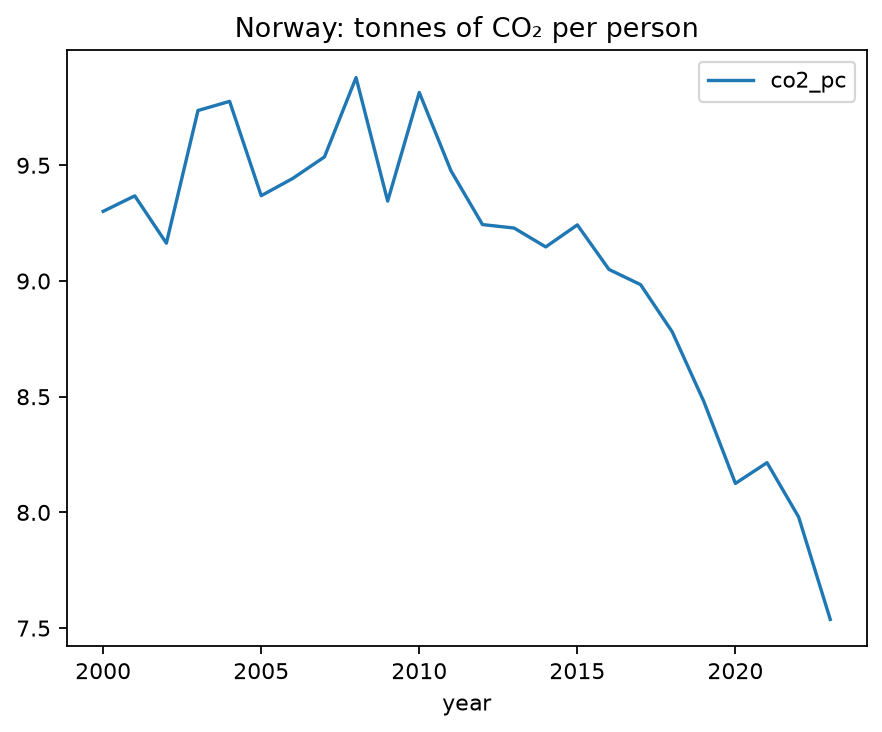

In [41]:
norway = emissions[emissions["country"] == "Norway"]

norway.plot(x="year", y="co2_pc", title="Norway: tonnes of CO₂ per person")

We come back to how to make publication-ready figures later.

## Additional resources

- [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) - the official quick
  tour, worth reading once you have met the ideas here
- [Indexing and selecting data](https://pandas.pydata.org/docs/user_guide/indexing.html) - the
  authoritative account of `[]`, `.loc` and `.iloc`, including why they differ
- [NumPy: the absolute basics for beginners](https://numpy.org/doc/stable/user/absolute_beginners.html)
  - arrays, dtypes and vectorization, from the source
- [Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html) - what
  `NaN` is, and every tool for detecting and handling it
- [SKL401](https://isabelhovdahl.github.io/skl401/) - lesson 1.10 introduces DataFrames, and lessons
  3.1 to 3.6 cover importing, subsetting, filtering and missing values more briefly

**Next week:** combining and summarizing - answering questions about *groups* of rows rather than
single ones, and joining two tables into one so that we can finally throw those aggregates out.